In [1]:
from utility import add_project_root_to_path
from pprint import pprint

add_project_root_to_path()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from experiments.experiment import GBMParameters
from experiments.synthetic_data import extract_gbm_params, generate_synthetic_data
from experiments.experiment import SyntheticDataDescription
from datetime import datetime

In [ ]:
DATA_DIR = Path("data/new_data")
ROWS_PER_DAY = 24 * 3600 // 12  # 7200

# All available pairs (csv_prefix -> display name)
ALL_PAIRS = [
    ("TUSDUSDT_USDCUSDT", "TUSD/USDC"),
    ("TUSDUSDT_USDPUSDT", "TUSD/USDP"),
    ("USDCUSDT_USDPUSDT", "USDC/USDP"),
    ("USDCUSDT_RADUSDT", "USDC/RAD"),
    ("ETHUSDT_USDT", "ETH/USDT"),
    ("BTCUSDT_USDT", "BTC/USDT"),
    ("BTCUSDT_ETHUSDT", "ETH/BTC"),
    ("ETHUSDT_BNBUSDT", "BNB/ETH"),
    ("DOGEUSDT_BTCUSDT", "DOGE/BTC"),
]

MONTH_ALIAS = {
    "2024-03": "volatile_market",
    "2024-04": "bear_market",
    "2024-08": "calm_market",
    "2024-11": "bull_market",
}

TIME_RANGE = {
    "volatile_market": (datetime(2024, 3, 1, 12, 0, 0), datetime(2024, 3, 2, 12, 0, 0)),
    "bear_market": (datetime(2024, 4, 1, 12, 0, 0), datetime(2024, 4, 2, 12, 0, 0)),
    "calm_market": (datetime(2024, 8, 1, 12, 0, 0), datetime(2024, 8, 2, 12, 0, 0)),
    "bull_market": (datetime(2024, 11, 1, 12, 0, 0), datetime(2024, 11, 2, 12, 0, 0)),
}

In [7]:
# ---- Choose pair here ----
CSV_PREFIX = "USDCUSDT_RADUSDT"
PAIR_NAME = "USDC/RAD"

CSV_PREFIX, PAIR_NAME = ALL_PAIRS[3]
# --------------------------

In [8]:
# Load historical data & fit GBM for each market type
hist_data = {}
gbm_params = {}

for month, alias in MONTH_ALIAS.items():
    csv_path = DATA_DIR / f"{CSV_PREFIX}-12s-{month}.csv"
    if not csv_path.exists():
        print(f"WARNING: {csv_path} not found, skipping")
        continue
    df = pd.read_csv(csv_path, nrows=ROWS_PER_DAY)
    hist_data[alias] = df
    params = extract_gbm_params(df[["price_A", "price_B"]].transpose().to_numpy())
    gbm_params[alias] = params
    print(f"{alias}: mu={params.mu}, S0={params.S0}, cov_mtrx={params.cov_matrix}")
    print()

volatile_market: mu=[-1.388595810293204e-08, -1.4999229541304207e-06], S0=[1.0004, 0.838], cov_mtrx=[[4.49947238e-09 4.84369965e-10]
 [4.84369965e-10 2.32016422e-07]]



In [9]:
# Generate synthetic GBM paths (3 seeds per market type for visual comparison)
N_SEEDS = 3

synth_data = {}  # synth_data[alias] = list of DataFrames
for alias, params in gbm_params.items():
    desc = SyntheticDataDescription(
        gbm_parameters=params,
        start_time=TIME_RANGE[alias][0],
        end_time=TIME_RANGE[alias][1],
        candle_interval="12s",
    )
    paths = []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        paths.append(generate_synthetic_data(desc))
    synth_data[alias] = paths
    print(f"{alias}: generated {N_SEEDS} synthetic paths")

volatile_market: generated 3 synthetic paths


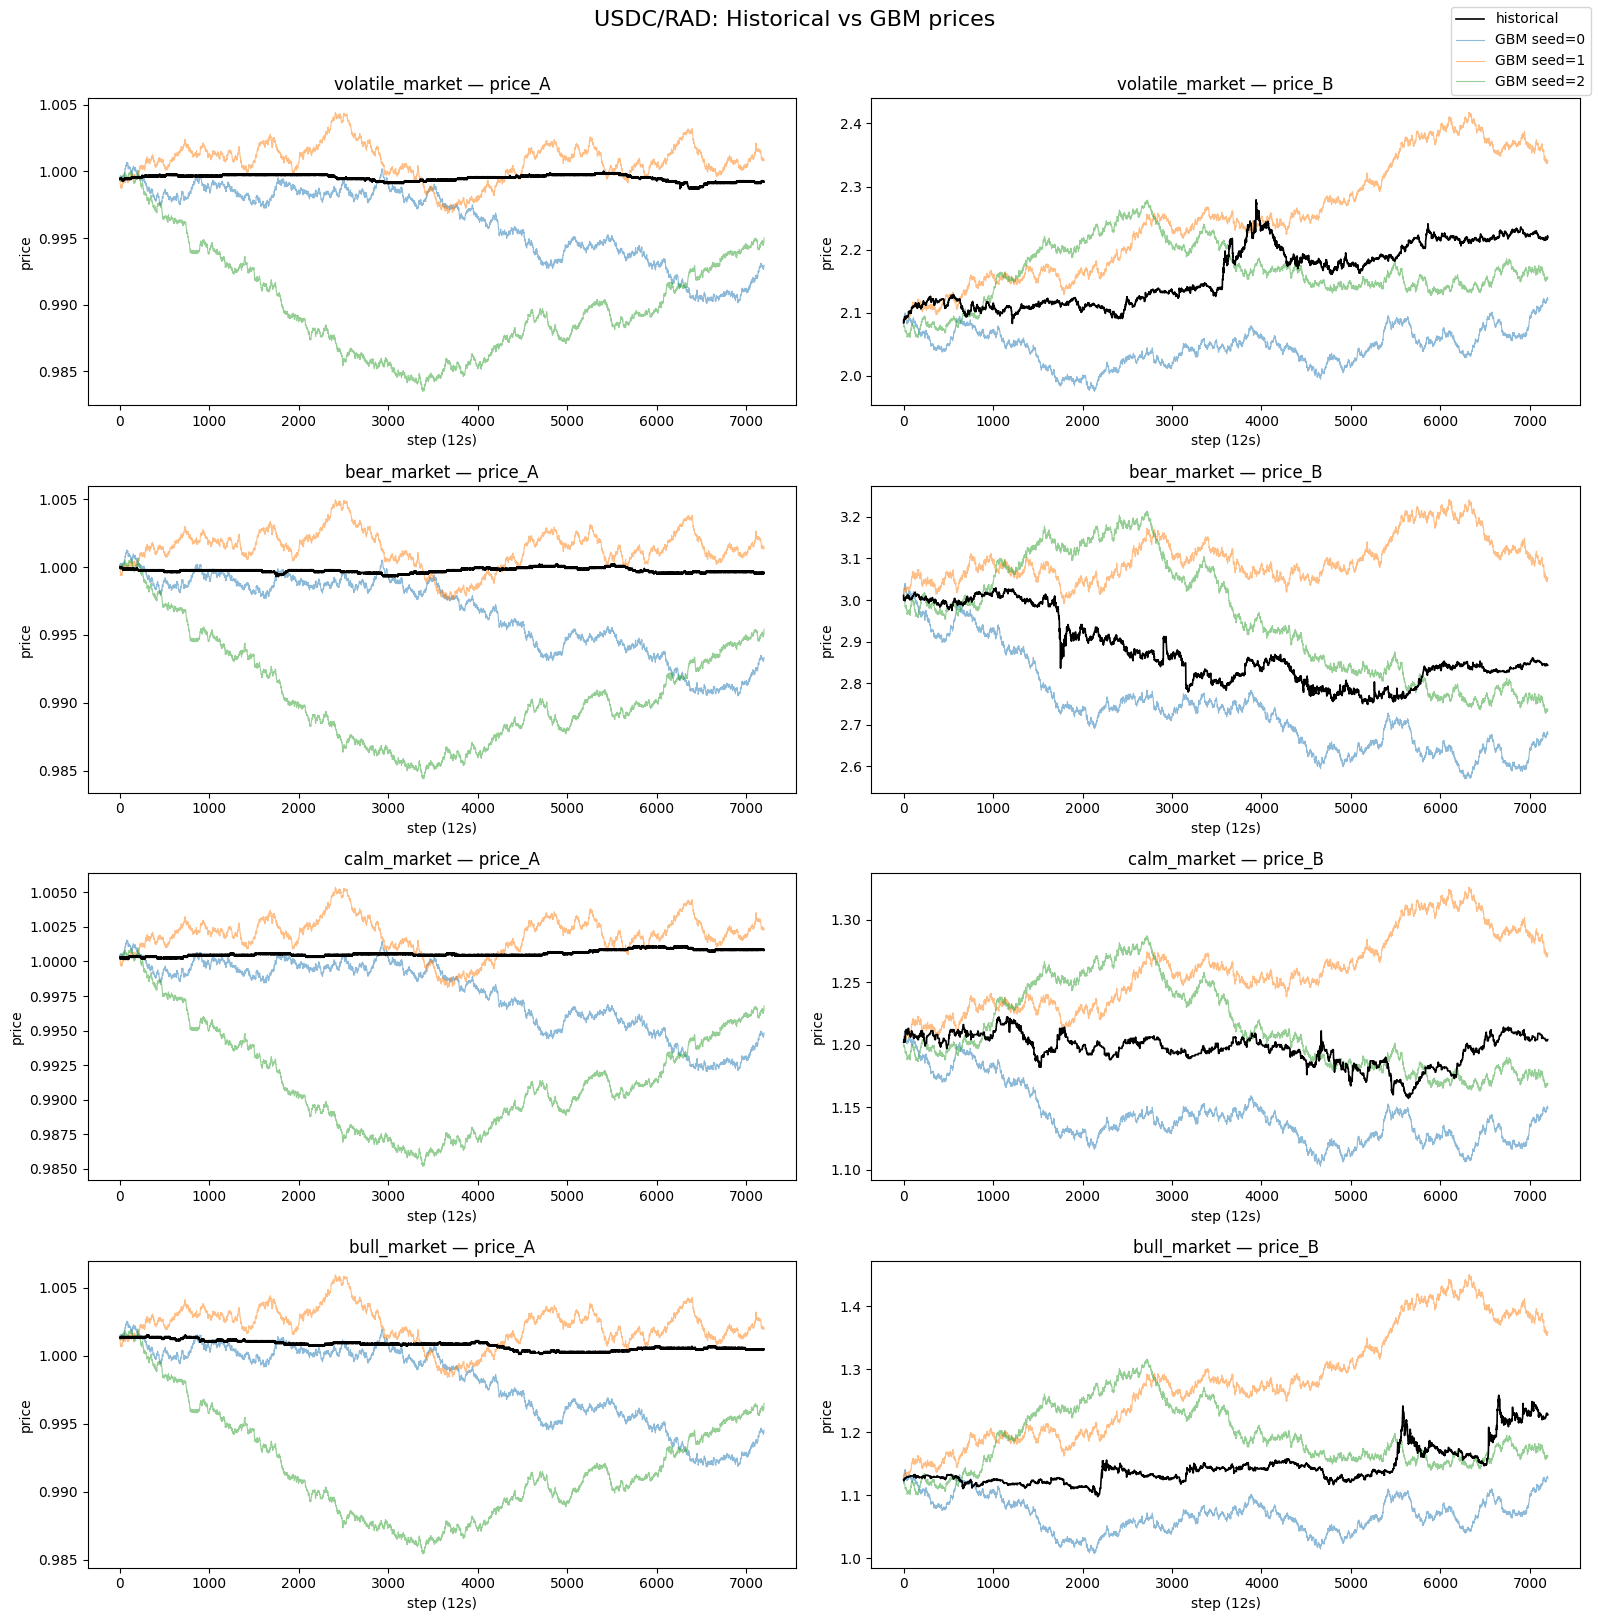

In [ ]:
# Plot: historical vs GBM for each market type
# Each subplot row = one market type, columns = price_A, price_B

market_types = [a for a in MONTH_ALIAS.values() if a in hist_data]
n_markets = len(market_types)

fig, axes = plt.subplots(n_markets, 2, figsize=(16, 4 * n_markets), squeeze=False)
fig.suptitle(f"{PAIR_NAME}: Historical vs GBM prices", fontsize=16, y=1.01)

for row, alias in enumerate(market_types):
    hdf = hist_data[alias]
    t_hist = np.arange(len(hdf))

    for col, price_col in enumerate(["price_A", "price_B"]):
        ax = axes[row, col]

        # Historical
        ax.plot(
            t_hist,
            hdf[price_col],
            color="black",
            linewidth=1.2,
            label="historical",
            zorder=3,
        )

        # GBM paths
        for i, sdf in enumerate(synth_data[alias]):
            t_synth = np.arange(len(sdf))
            ax.plot(
                t_synth,
                sdf[price_col],
                alpha=0.5,
                linewidth=0.8,
                label=f"GBM seed={i}" if row == 0 and col == 0 else None,
            )

        ax.set_title(f"{alias} — {price_col}")
        ax.set_xlabel("step (12s)")
        ax.set_ylabel("price")

# Single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

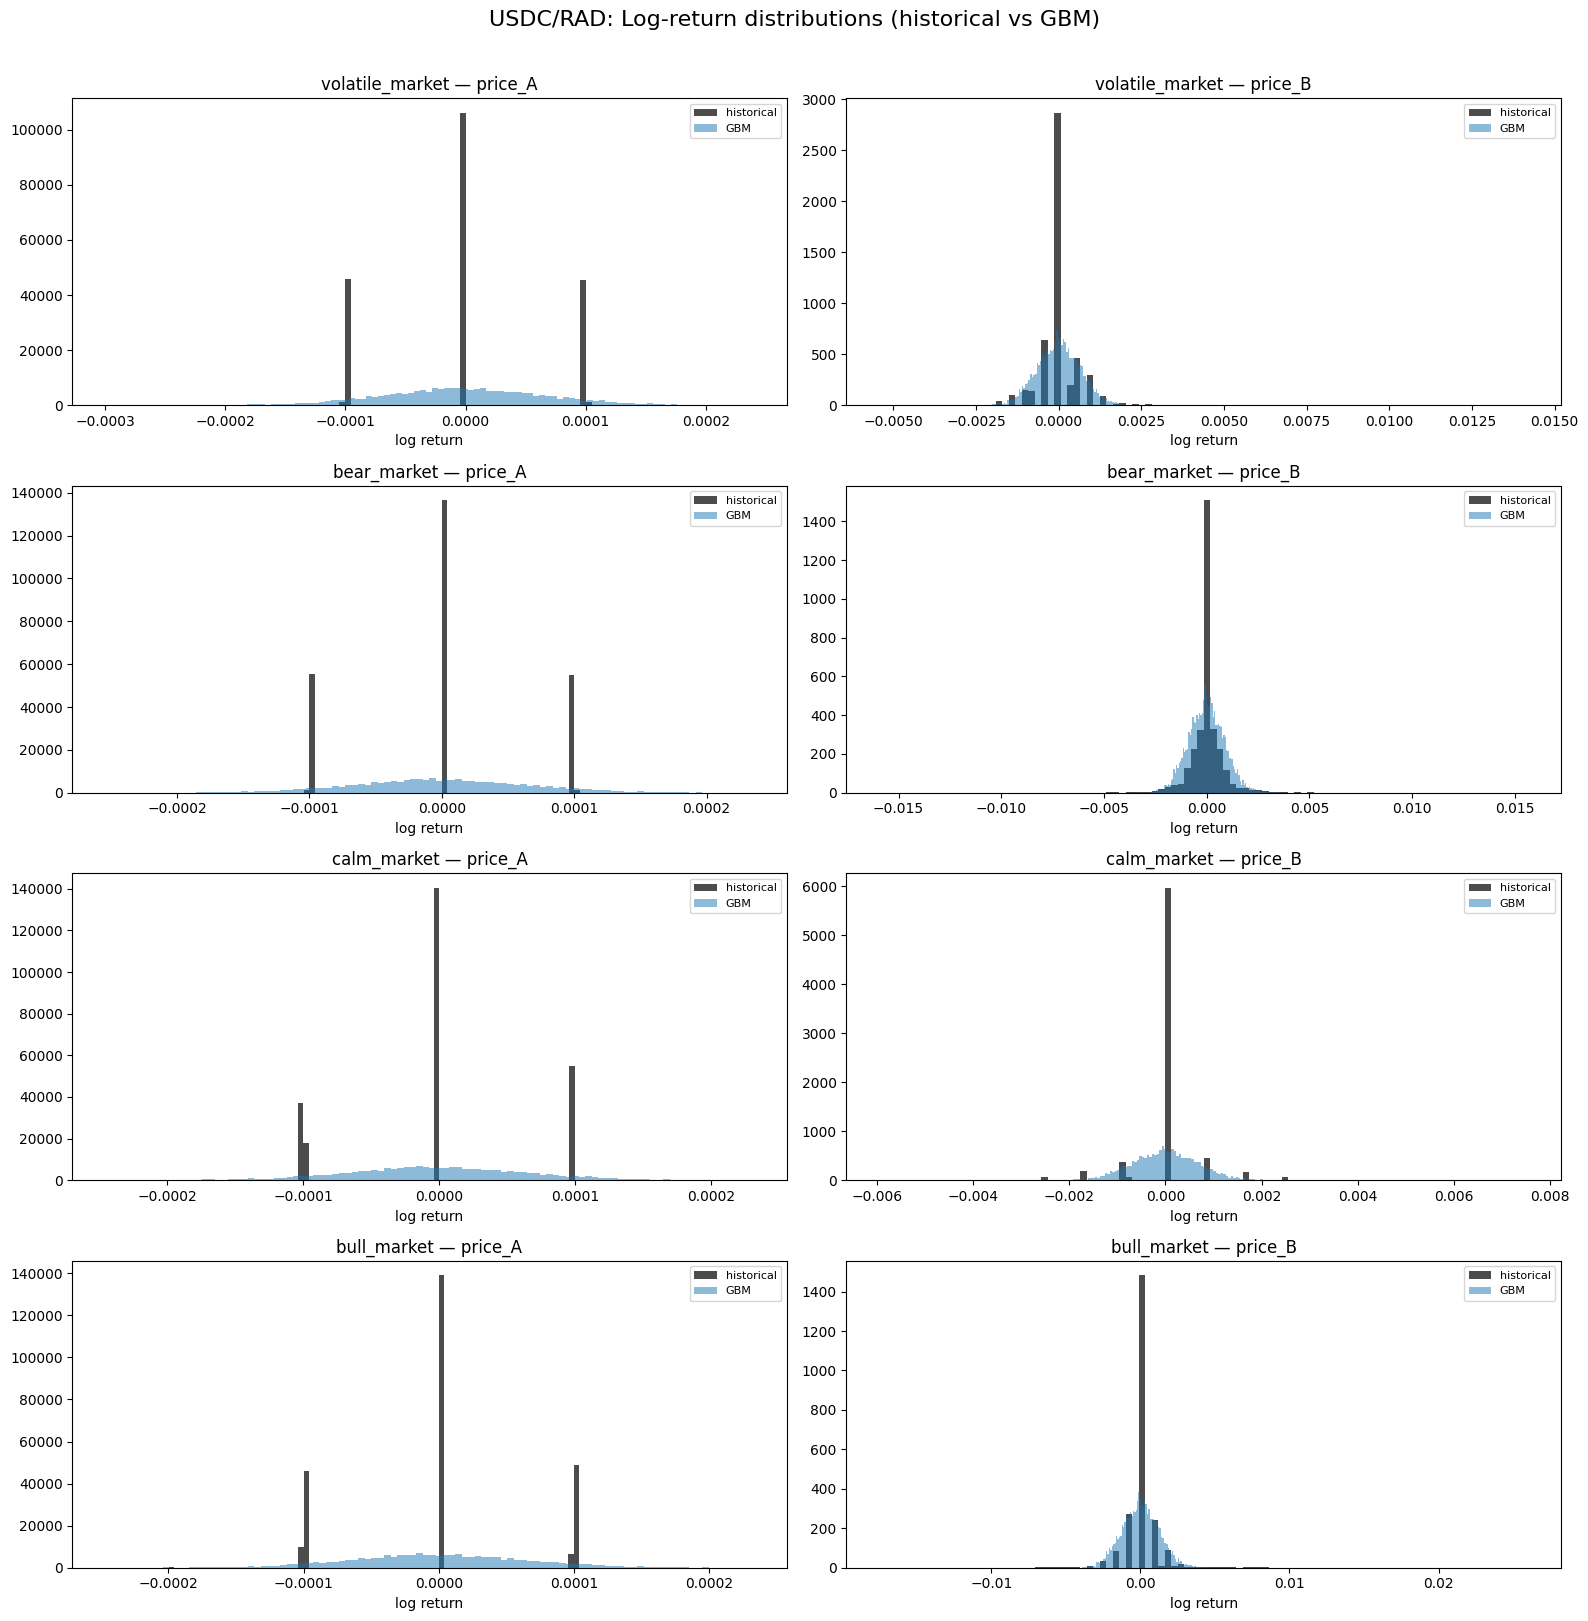

In [ ]:
# Compare log-return distributions: historical vs GBM

fig, axes = plt.subplots(n_markets, 2, figsize=(16, 4 * n_markets), squeeze=False)
fig.suptitle(
    f"{PAIR_NAME}: Log-return distributions (historical vs GBM)", fontsize=16, y=1.01
)

for row, alias in enumerate(market_types):
    hdf = hist_data[alias]

    for col, price_col in enumerate(["price_A", "price_B"]):
        ax = axes[row, col]

        # Historical log-returns
        hist_prices = hdf[price_col].values
        hist_lr = np.log(hist_prices[1:] / hist_prices[:-1])

        ax.hist(
            hist_lr,
            bins=100,
            density=True,
            alpha=0.7,
            color="black",
            label="historical",
        )

        # GBM log-returns (first seed)
        sdf = synth_data[alias][0]
        synth_prices = sdf[price_col].values
        synth_lr = np.log(synth_prices[1:] / synth_prices[:-1])

        ax.hist(
            synth_lr, bins=100, density=True, alpha=0.5, color="tab:blue", label="GBM"
        )

        ax.set_title(f"{alias} — {price_col}")
        ax.set_xlabel("log return")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

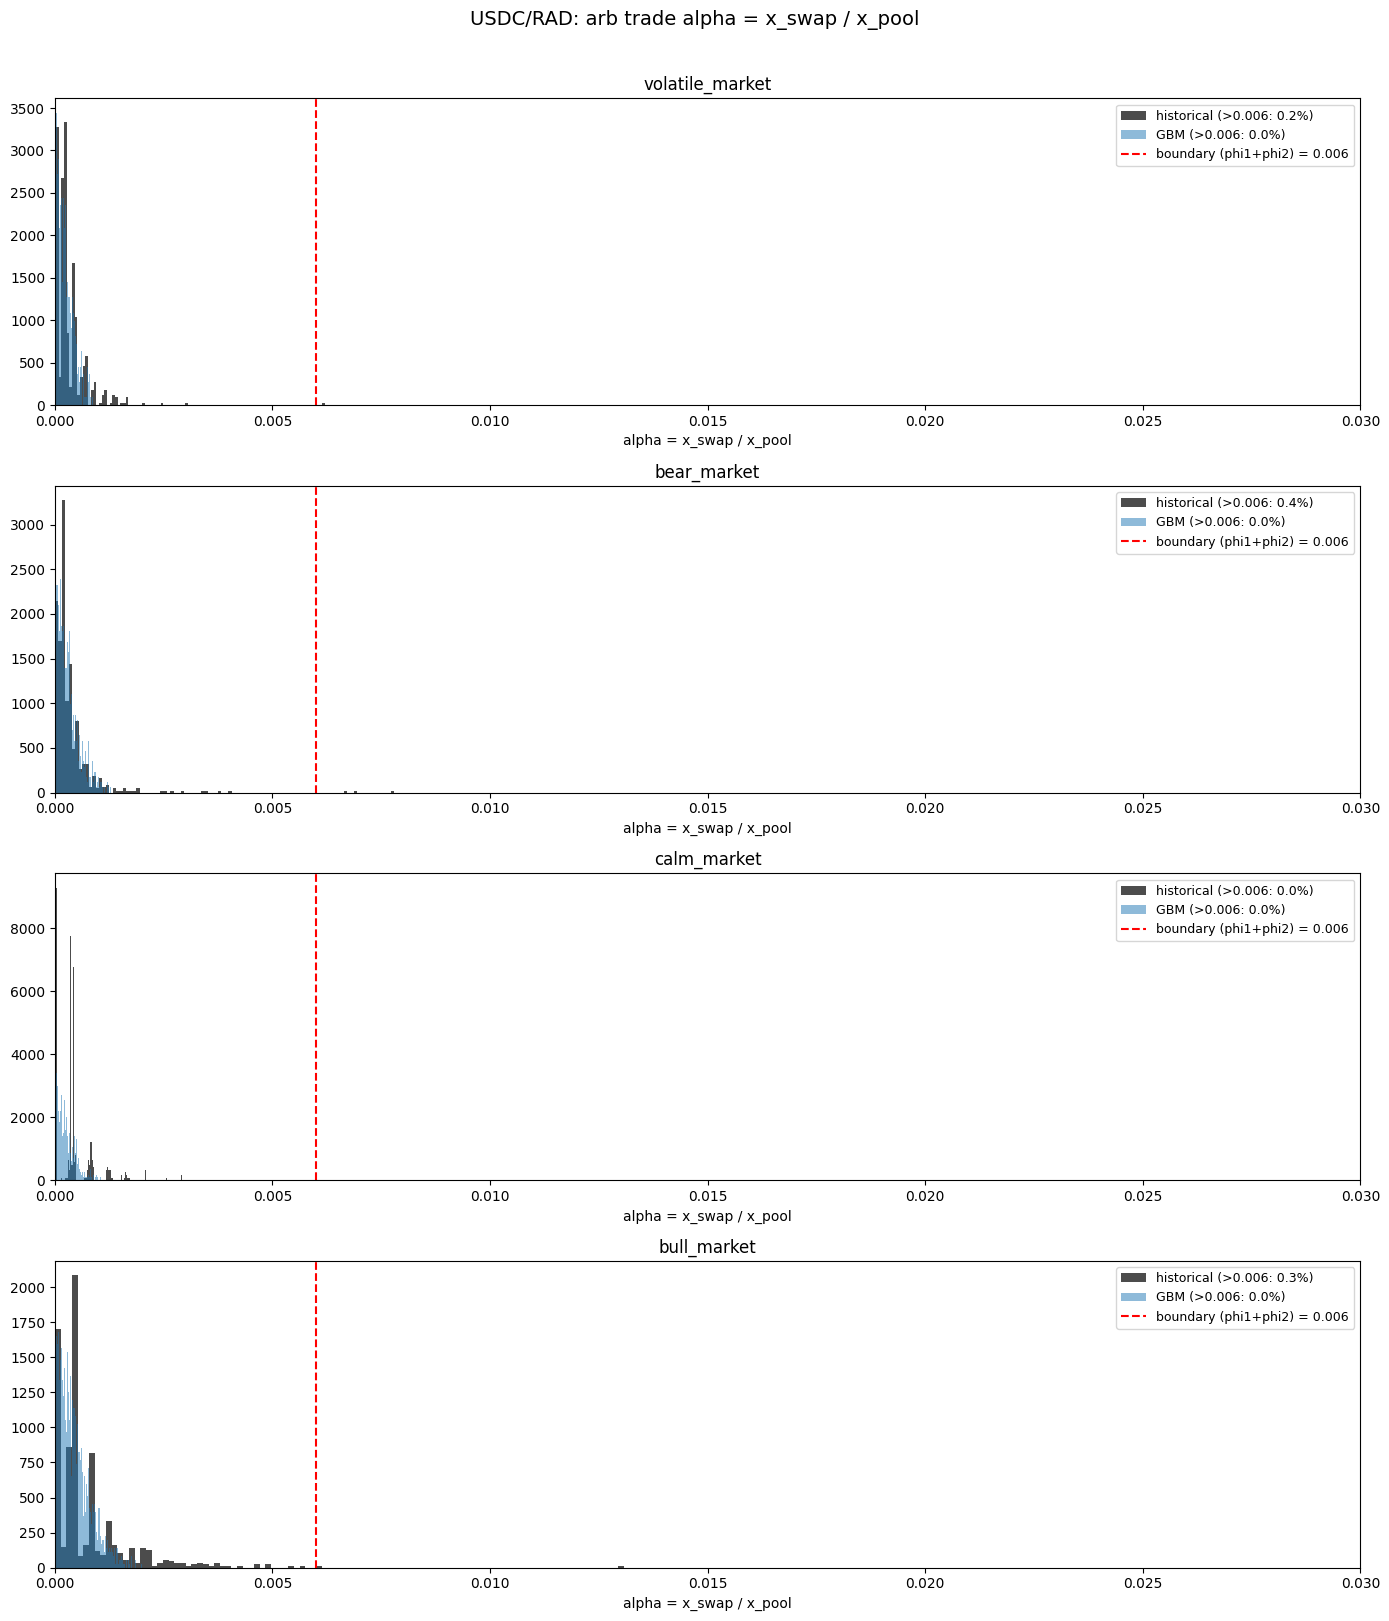

In [ ]:
# Compare alpha (= optimal_swap_size / pool_reserve) distributions
# Simulate a CPMM pool step by step: at each step the arb rebalances the pool
# to fair price, and we record alpha = x_arb / x_pool.


def simulate_alphas(prices_a, prices_b, fee_rate=0.003):
    """Walk a CPMM pool through a price series and return arb trade alphas."""
    # Initial pool: x * y = k, with pool price = price_A/price_B
    ratio_0 = prices_a[0] / prices_b[0]
    x = 1.0  # normalised reserves
    y = ratio_0  # so that y/x = price_a/price_b
    beta = 1 - fee_rate

    alphas = []
    for i in range(1, len(prices_a)):
        q = prices_a[i] / prices_b[i]  # fair a-to-b price ratio
        pool_price = y / x  # current pool price (= quantity_b / quantity_a)

        if pool_price > q:
            # pool overprices A relative to B  ->  arb sells A to pool
            opt_dx = (np.sqrt(x * y * beta / q) - x) / beta
            if opt_dx > 0:
                alpha = opt_dx / x
                alphas.append(alpha)
                # execute trade: pool gets opt_dx of A, gives out dy of B
                dx_net = opt_dx * beta
                dy = y * dx_net / (x + dx_net)
                x += opt_dx
                y -= dy
            else:
                alphas.append(0.0)
        elif pool_price < q:
            # inverse: arb sells B to pool
            # work in inverse coordinates
            xi, yi = y, x
            qi = 1.0 / q
            opt_dx = (np.sqrt(xi * yi * beta / qi) - xi) / beta
            if opt_dx > 0:
                alpha = opt_dx / xi  # relative to B-reserve
                alphas.append(alpha)
                dx_net = opt_dx * beta
                dy = yi * dx_net / (xi + dx_net)
                y += opt_dx  # B-reserve grows
                x -= dy  # A-reserve shrinks
            else:
                alphas.append(0.0)
        else:
            alphas.append(0.0)

    return np.array(alphas)


BOUNDARY = 0.006  # typical phi_1 + phi_2

fig, axes = plt.subplots(n_markets, 1, figsize=(14, 4 * n_markets), squeeze=False)
fig.suptitle(f"{PAIR_NAME}: arb trade alpha = x_swap / x_pool", fontsize=14, y=1.01)

for row, alias in enumerate(market_types):
    ax = axes[row, 0]
    hdf = hist_data[alias]

    hist_alphas = simulate_alphas(hdf["price_A"].values, hdf["price_B"].values)
    sdf = synth_data[alias][0]
    synth_alphas = simulate_alphas(sdf["price_A"].values, sdf["price_B"].values)

    # Filter out zeros for cleaner histogram
    hist_nz = hist_alphas[hist_alphas > 0]
    synth_nz = synth_alphas[synth_alphas > 0]

    ax.hist(
        hist_nz,
        bins=100,
        density=True,
        alpha=0.7,
        color="black",
        label=f"historical (>{BOUNDARY}: {(hist_nz > BOUNDARY).mean():.1%})",
    )
    ax.hist(
        synth_nz,
        bins=100,
        density=True,
        alpha=0.5,
        color="tab:blue",
        label=f"GBM (>{BOUNDARY}: {(synth_nz > BOUNDARY).mean():.1%})",
    )

    ax.axvline(
        BOUNDARY,
        color="red",
        linestyle="--",
        label=f"boundary (phi1+phi2) = {BOUNDARY}",
    )
    ax.set_title(alias)
    ax.set_xlabel("alpha = x_swap / x_pool")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 0.03)

plt.tight_layout()
plt.show()